# Autoencoding and Self-Supervision

In [1]:
# Import dependencies
import torch
import torchvision
from torchvision import transforms
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import *
from sklearn.preprocessing import StandardScaler
import numpy as np
import matplotlib.pyplot as plt
#from idlmam import *
from sklearn.metrics import accuracy_score

In [2]:
# Import the dl_utils.py file
import sys, os

# Add the project root to the python path
sys.path.insert(0, os.path.abspath("../DL_utils_EZA")) # Goes up one level from current folder

# Autoreload: picks up edits to dl_utils.py without restarting the kernel
%load_ext autoreload
%autoreload 2

# Import my own utilities
from dl_utils import * #import all my functions

print(" dl_utils loaded")

# Verification of CUDA present and force deterministic bahaviour for reproducibility with forced GPU usage

torch.backends.cudnn.benchmark = False  # False is better for RNNs with variable input sizes, True for CNNs

if torch.cuda.is_available():
    device = torch.device('cuda')
else:
    device = torch.device('cpu')

print(f'Device available: {device}')

 dl_utils loaded
Device available: cuda


/home/efrain/Documents/Bio-AI-foundations/DL_utils_EZA/dl_utils.py:9: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from tqdm.autonotebook import tqdm


## Implementing a *Principal Component Analysis* (PCA) as an Autoencoder
We define the network function: $$f(x) = xWW^{T}$$

In [3]:
# Define constants for features
D = 28*28     # Values in the input
n = 2         # Hidden layers size 
C = 1         # Number of channles
classes = 10  # Number of classes

In [4]:
# View class to conver the image shape
class View(nn.Module):
    def __init__(self, *shape):
        super(View, self).__init__()
        self.shape = shape
    def forward(self, input):
        return input.view(*self.shape) 

In [5]:
# Define the TransposeLinear class
class TransposeLinear(nn.Module):   # Class extens nn.Module and all PyTorch layers extend this
    def __init__(self, linearLayer, bias=True):
        """ 
        LinearLayer: is the layer that we want to use the transpose of to produce the ouput of this layer. 
                     The linea layer represents W, and this layer represents W^T.
        bias: if True, creates a new bias term b that is learned separately from what is in linearLayer. If
              false no bias vector is used.
        """

        super().__init__()
        self.weight = linearLayer.weight     # Creates the new variable weight to store a reference to original weight
        if bias:
            self.bias = nn.Parameter(torch.Tensor(linearLayer.weight.shape[1])) # Creates new bias vector
        else:
            self.register_parameter('bias', None)
        
    def forward(self, x):
                return F.linear(x, self.weight.t(), self.bias)
    

In [6]:
# Implement PCA

# Define the linear layer
linearLayer = nn.Linear(D, n, bias=False)

# Encoder flattens and use the linear layer
pca_encoder = nn.Sequential(
    nn.Flatten(),
    linearLayer
    )

    # Decoder uses the TransposeLienar layer.
pca_decoder = nn.Sequential(
    TransposeLinear(linearLayer, bias=False), 
    View(-1, 1, 28, 28)   # Shapes data back to original form
    )

    # Defineas a final PCA model with encoder, decoder
pca_model = nn.Sequential(
    pca_encoder,
    pca_decoder
    )

    # Add the constraint
nn.init.orthogonal_(linearLayer.weight)

    #Original Loss function
mse_loss = nn.MSELoss()

In [7]:
# The PCA loss function
def mseWithOrthoLoss(x, y):
    W = linearLayer.weight   
    I = torch.eye(W.shape[0]).to(device) # Identity matrix target for regularization

    normal_loss = mse_loss(x, y)  # Computes original loss
    regularization_loss = 0.1*mse_loss(torch.mm(W, W.t()), I) # computes regularizer penalty
          
    return normal_loss + regularization_loss 

### Implementing PCA with PyTorch
Crate a Wrapper for the MNIST dataset. It will transform (x, y) to (x , x)

In [8]:
# Add the class AtoEncodeDataset
class AutoEncodeDataset(Dataset):
    """  
    Takes a dataset with (x, y) and convets to (x, x)
    """

    def __init__(self, dataset):
        self.dataset = dataset
    
    def __len__(self):
        return len(self.dataset)
    
    def __getitem__(self, idx):
        x, y = self.dataset.__getitem__(idx)
        return x, x

In [9]:
# Load the MNIST dataset and transform it into (x, x)
train_data = (AutoEncodeDataset(torchvision.datasets.MNIST("./data/Autoencoder", train=True, 
                                                           transform=transforms.ToTensor(), 
                                                           download=True))
)

test_data_xy = torchvision.datasets.MNIST("./data/Autoencoder", train=True,
                                          transform=transforms.ToTensor(),
                                          download=True
)

test_data_xx = AutoEncodeDataset(test_data_xy)



In [10]:
# Data loaders
train_loader = DataLoader(train_data, 
                          batch_size=128, 
                          shuffle=True,
                          num_workers=4,
                          pin_memory=True,
                          persistent_workers=True,
                          drop_last=True
)

test_loader = DataLoader(test_data_xx, 
                        batch_size=128*2,
                        shuffle=False,
                        num_workers=4,
                        persistent_workers=True,
                        pin_memory=True
)

In [11]:
# Train the network
train_network_EZA(pca_model,
                  mseWithOrthoLoss,
                  train_loader,
                  test_loader=test_loader,
                  epochs=30,
                  device=device
)

Epoch: 100%|██████████| 30/30 [02:52<00:00,  5.76s/it]


,epoch,total time,train loss,test loss
0,0,2.557826,0.063807,0.057976
1,1,2.250725,0.057900,0.057891
2,2,2.610467,0.057877,0.057870
3,3,3.028459,0.057882,0.057878
4,4,2.994243,0.057897,0.057909
5,5,3.174298,0.057884,0.057873
6,6,2.966475,0.057892,0.057897
7,7,3.048364,0.057894,0.057894
8,8,2.989843,0.057888,0.057878
9,9,2.970488,0.057895,0.057964


### Visualizing PCA results

In [12]:
def encode_batch(encoder, dataset_to_encode):
    """ 
    encoder: The PyTorch network that takes in a dataset and converts it to a new dimension
    dataset_to_encode: a PyTorch `dataset` object that we want to convert

    Returns a tuple (projected, labels) where `projected` is the encoded version of the dataset,
    and `labels` are the original labels provided by the `dataset_to_encode`.
    """

    projected = []
    labels = []     # The spaces to store the results
    encoder = encoder.eval()  # Switches to eval mode
    encoder = encoder.cpu()   # Moves to CPU for simplicity

    with torch.no_grad():  # No training
        for x, y in DataLoader(dataset_to_encode, batch_size=128):
            z = encoder(x.cpu())    # encodes the original data
            projected.append(z.numpy())   # Stores the encoded version and label
            labels.append(y.cpu().numpy().ravel())  
    
    projected = np.vstack(projected) # Turns the result into single large Numpy arrays
    labels = np.hstack(labels)
    return projected, labels

In [13]:
# Project the data
projected, labels = encode_batch(pca_encoder, test_data_xy)

<Axes: >

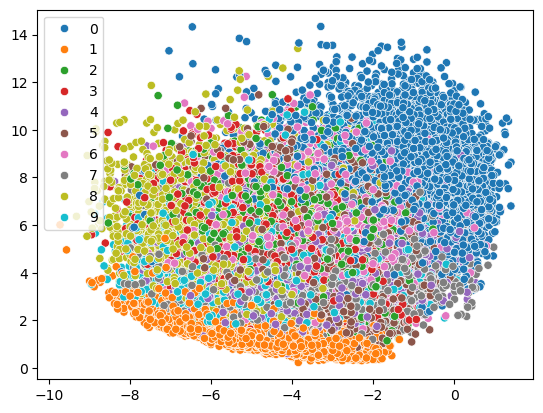

In [14]:
# Plots the results
sns.scatterplot(x=projected[:,0], y=projected[:,1], 
                hue=[str(i) for i in labels], 
                hue_order=[str(j) for j in range(10)],
                legend='full')


In [15]:
# Create a function to plot the result correlations x vs decoded x
def showEncodeDecode(encode_decode, x):
    """ 
    encode_decode: the PyTorch Module that does the encoding and decoding steps at once
    x: the input to plot as is, and after encoding and decoding it
    """

    encode_decode = encode_decode.eval()  # Eval mode
    encode_decode = encode_decode.cpu() #  use the CPU

    with torch.no_grad():  # Not training mode
        x_recon = encode_decode(x.cpu())
    f, axarr = plt.subplots(1,2)
    axarr[0].imshow(x.numpy()[0,:])
    axarr[1].imshow(x_recon.numpy()[0,0,:])

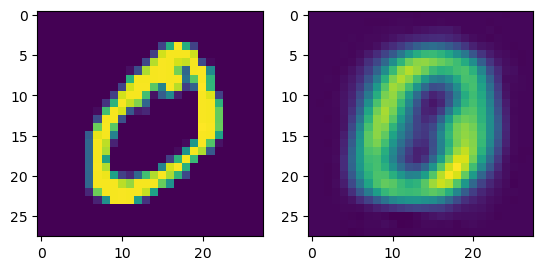

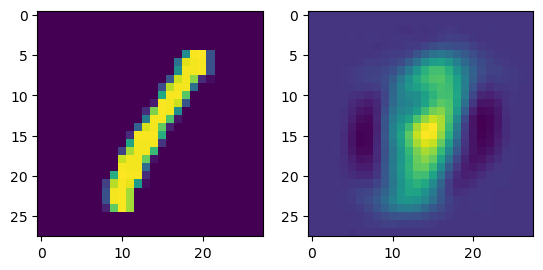

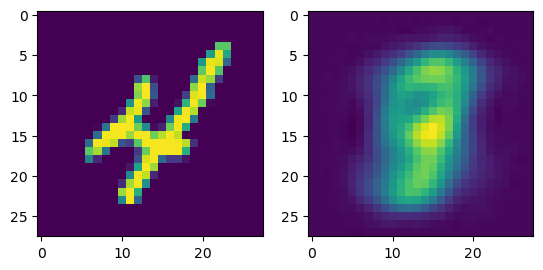

In [16]:
# Use the function to plot the results for encoder/decoder
showEncodeDecode(pca_model, test_data_xy[1][0])
showEncodeDecode(pca_model, test_data_xy[3][0])
showEncodeDecode(pca_model, test_data_xy[9][0])

### A simple nonlinear PCA (Autoencoder)

In [17]:
pca_nonlinear_encode = nn.Sequential(
    nn.Flatten(),
    nn.Linear(D, n),
    nn.Tanh(),   # Nonlinearity to make it a nonlinear autoencoder
)

pca_nonlinear_decoder = nn.Sequential(
    nn.Linear(n, D),
    View(-1, 1, 28, 28)
)

pca_nonlinear = nn.Sequential(
    pca_nonlinear_encode,
    pca_nonlinear_decoder
)

In [18]:
#  reset workers before new run
import gc
gc.collect()
torch.cuda.empty_cache()  # Free any leftover VRAM from previous run

torch.backends.cudnn.benchmark = False  # False for training FC

# Train the nonlinear autoencoder
train_network_EZA(pca_nonlinear,
                  mse_loss,
                  train_loader,
                  test_loader=test_loader,
                  epochs=30,
                  device=device
)

Epoch: 100%|██████████| 30/30 [02:47<00:00,  5.59s/it]


,epoch,total time,train loss,test loss
0,0,2.358562,0.135132,0.070031
1,1,2.399490,0.066737,0.065785
2,2,3.017958,0.065493,0.065162
3,3,2.980738,0.064787,0.064348
4,4,2.972337,0.063837,0.063233
5,5,3.031666,0.062481,0.061610
6,6,3.133029,0.060594,0.059541
7,7,2.940549,0.058701,0.057998
8,8,2.953406,0.057537,0.057162
9,9,3.022913,0.056934,0.056726


<Axes: >

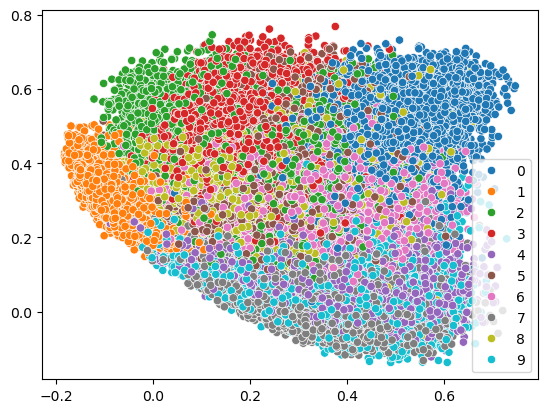

In [19]:
projected_nonlinear, labels_nonlinear = encode_batch(pca_nonlinear_encode, test_data_xy)
sns.scatterplot(x=projected_nonlinear[:,0], y=projected_nonlinear[:,1], 
                hue=[str(i) for i in labels_nonlinear], 
                hue_order=[str(j) for j in range(10)],
                legend='full')

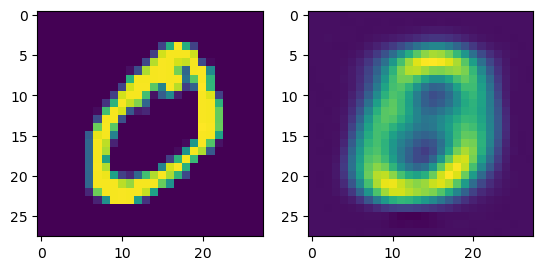

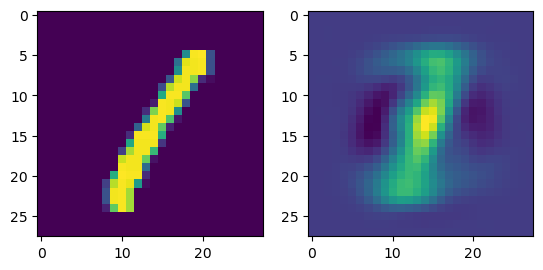

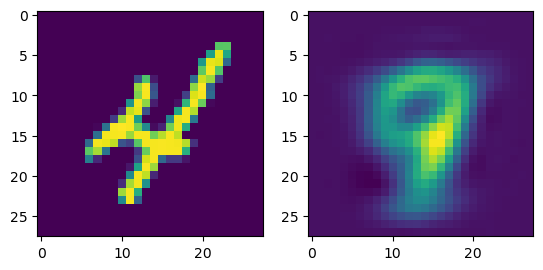

In [20]:
showEncodeDecode(pca_nonlinear, test_data_xy[1][0])
showEncodeDecode(pca_nonlinear, test_data_xy[3][0])
showEncodeDecode(pca_nonlinear, test_data_xy[9][0])

## Designing Autoencoding Neural Networks
**Autoencoding networks** can be use for *outlier detection*.\
To construct autoencoder network, the usual approach is to make a symmetric architecture between the encoder\
and autoencoder, but the do not need to be symetrical.

We use the helper function `getLayer` to create a single hidden layer.

In [ ]:
def getLayer(in_size, out_size):
    """ 
    in_size: number of neurons/features in the input
    out_size: the size of the output of the layer
    bias: if True, creates a bias term for this layer. If False, no bias is used.
    """

    return nn.Sequential(
        nn.Linear(in_size, out_size),
        nn.BatchNorm1d(out_size),  # Normalizes the output of the linear layer
        nn.ReLU()
    )

In [ ]:
# Define the encoder and decoder for a deeper autoencoder
auto_encoder = nn.Sequential(
    nn.Flatten(),
    getLayer(D, D//2),
    getLayer(D//2, D//3),
    getLayer(D//3, D//4),
    nn.Linear(D//4, n)
)

auto_decoder = nn.Sequential(
    getLayer(n, D//4),
    getLayer(D//4, D//3),
    getLayer(D//3, D//2),
    nn.Linear(D//2, D),
    View(-1, 1, 28, 28)
)

auto_encode_decode = nn.Sequential(
    auto_encoder,
    auto_decoder
)
    #Original Loss function
mse_loss = nn.MSELoss()

In [ ]:
#  reset workers before new run
import gc
gc.collect()
torch.cuda.empty_cache()  # Free any leftover VRAM from previous run

torch.backends.cudnn.benchmark = False  # False for training FC

# Train the deeper autoencoder
train_network_EZA(auto_encode_decode,
                  mse_loss,
                  train_loader,
                  test_loader=test_loader,
                  epochs=30,
                  device=device
)

In [ ]:
# Visualize the results for the deeper autoencoder
projected, labels = encode_batch(auto_encoder, test_data_xy)
sns.scatterplot(x=projected[:,0], y=projected[:,1], 
                hue=[str(i) for i in labels], 
                hue_order=[str(j) for j in range(10)],
                legend='full')

In [ ]:
# Lood at examples of the deeper autoencoder
showEncodeDecode(auto_encode_decode, test_data_xy[1][0])
showEncodeDecode(auto_encode_decode, test_data_xy[3][0])
showEncodeDecode(auto_encode_decode, test_data_xy[9][0])
showEncodeDecode(auto_encode_decode, test_data_xy[15][0])

#  Bigger Autoencoders
Making the target size *larger* than the original

In [ ]:
# Making a bigger autoencoder that increases D
auto_encoder_big = nn.Sequential(
    nn.Flatten(),
    getLayer(D, D*2),
    getLayer(D*2, D*2),
    getLayer(D*2, D*2),
    nn.Linear(D*2, D*2)
)

auto_decoder_big = nn.Sequential(
    getLayer(D*2, D*2),
    getLayer(D*2, D*2),
    getLayer(D*2, D*2),
    nn.Linear(D*2, D),
    View(-1, 1, 28, 28)
)
auto_encode_decode_big = nn.Sequential(
    auto_encoder_big,
    auto_decoder_big
)

In [ ]:
#  reset workers before new run
import gc
gc.collect()
torch.cuda.empty_cache()  # Free any leftover VRAM from previous run

torch.backends.cudnn.benchmark = False  # False for training FC

# Train the bigger autoencoder
train_network_EZA(auto_encode_decode_big,
                  mse_loss,
                  train_loader,
                  test_loader=test_loader,
                  epochs=30,
                  device=device
)

In [ ]:
# Test results for the bigger autoencoder
showEncodeDecode(auto_encode_decode_big, test_data_xy[1][0])
showEncodeDecode(auto_encode_decode_big, test_data_xy[5][0])
showEncodeDecode(auto_encode_decode_big, test_data_xy[11][0])
showEncodeDecode(auto_encode_decode_big, test_data_xy[19][0])

### Robustness to noise of the autoencoder 
Test if a autoencoder with $D' = 2$ is better to $D' = 2*D$

In [ ]:
# Create a function to add noise to the data and test the denoising capabilities of the autoencoder
normal = torch.distributions.Normal(0, 0.5) # Normal distribution with mean 0 and std 0.5

def addNoise(x, device='cpu'):
    """ 
    x: the input data to which we want to add noise
    device: the device to perform the operation on (default is 'cpu')
    """

    return x + normal.sample(sample_shape=torch.Size(x.shape)).to(device)

In [ ]:
# Visulize the noisy data with the bigger autoencoder
showEncodeDecode(auto_encode_decode_big, addNoise(test_data_xy[1][0]))
showEncodeDecode(auto_encode_decode_big, addNoise(test_data_xy[5][0]))

In [ ]:
# Visulize the noisy data with the smaller autoencoder
showEncodeDecode(auto_encode_decode, addNoise(test_data_xy[1][0]))
showEncodeDecode(auto_encode_decode, addNoise(test_data_xy[5][0]))

**The smaller autoencoer is more robust**

## Denoising Autoencoders
A denoising autoencoder adds noise to the encoder's input while still expecting the decoder to produce a clean image.
### Denoising with Gaussian noise
We add a new layer at the beginning of the encoder subnetwork to add nois to the input ***only when we are training*** the `auto_encoder_big`.

In [ ]:
# Add a class to add gausian noise to the data
class AdditiveGaussianNoise(nn.Module):
    def __init__(self):
        super().__init__()

    def forward(self, x):
        if self.training:  # Only add noise during training
            return addNoise(x, device=device)
        else:
            return x

In [ ]:
dnauto_encoder_big = nn.Sequential(
    nn.Flatten(),
    AdditiveGaussianNoise(),  # Adds noise to the data
    getLayer(D, D*2),
    getLayer(D*2, D*2),
    getLayer(D*2, D*2),
    nn.Linear(D*2, D*2)
)

dnauto_decoder_big = nn.Sequential(
    getLayer(D*2, D*2),
    getLayer(D*2, D*2),
    getLayer(D*2, D*2),
    nn.Linear(D*2, D),
    View(-1, 1, 28, 28)
)

dnauto_encode_decode_big = nn.Sequential(
    dnauto_encoder_big,
    dnauto_decoder_big
)

In [ ]:
#  reset workers before new run
import gc
gc.collect()
torch.cuda.empty_cache()  # Free any leftover VRAM from previous run

torch.backends.cudnn.benchmark = False  # False for training FC
    
#Original Loss function
mse_loss = nn.MSELoss()

train_network_EZA(dnauto_encode_decode_big,
                  mse_loss,
                  train_loader,
                  test_loader=test_loader,
                  epochs=30,
                  device=device
)

In [ ]:
# compare the results of the denoising autoencoder with the regular autoencoder
showEncodeDecode(dnauto_encode_decode_big, test_data_xy[6][0])
showEncodeDecode(dnauto_encode_decode_big, addNoise(test_data_xy[6][0]))

### Denoising with Dropout
Dropout: with some probability $p$, zero out any given feature value.\
Dropout with $p = 20$%

In [ ]:
dnauto_encoder_dropout = nn.Sequential(
    nn.Flatten(),
    nn.Dropout(0.2),  # 20% of the data is dropped out
    getLayer(D, D*2),
    nn.Dropout(0.2),  # 20% of the data is dropped out
    getLayer(D*2, D*2),
    nn.Dropout(0.2),  # 20% of the data is dropped out
    getLayer(D*2, D*2), 
    nn.Dropout(),
    nn.Linear(D*2, D*2)
)

dnauto_decoder_dropout = nn.Sequential(
    getLayer(D*2, D*2),
    nn.Dropout(0.2),  # 20% of the data is dropped out
    getLayer(D*2, D*2),
    nn.Dropout(0.2),  # 20% of the data is dropped out
    getLayer(D*2, D*2),
    nn.Dropout(0.2),  # 20% of the data is dropped out
    nn.Linear(D*2, D),
    View(-1, 1, 28, 28)
)

dnauto_encode_decode_dropout = nn.Sequential(
    dnauto_encoder_dropout,
    dnauto_decoder_dropout
)

In [ ]:

#  reset workers before new run
import gc
gc.collect()
torch.cuda.empty_cache()  # Free any leftover VRAM from previous run

torch.backends.cudnn.benchmark = False  # False for training FC

train_network_EZA(dnauto_encode_decode_dropout,
                  mse_loss,
                  train_loader,
                  test_loader=test_loader,
                  epochs=30,
                  device=device
)

In [ ]:
# See results and compare 
showEncodeDecode(dnauto_encode_decode_dropout, test_data_xy[21][0])
showEncodeDecode(dnauto_encode_decode_dropout, addNoise(test_data_xy[21][0]))
showEncodeDecode(dnauto_encode_decode_dropout, nn.Dropout()(test_data_xy[21][0]))

## Autoregressive models for time series and sequences
### Implementing a char-RNN autoregressive text model
We will use the Andrej Karpathy data with 100,000 characteres from Shakespeare.

In [3]:
# Import dependencies to download the data
from io import BytesIO
from zipfile import ZipFile
from urllib.request import urlopen
import re

In [4]:
# Load data
all_data = []

resp = urlopen("http://cs.stanford.edu/people/karpathy/shakespeare.txt") # Replace with the actual URL of the data
shakespeare_4_mill = resp.read()
shakespeare_4_mill = shakespeare_4_mill.decode("utf-8").lower() # Decodes the data from bytes to string

Nowwe build a vocabulary $\sum$ of all the characteres in the dataset

In [5]:
vocab2indx = {}
for char in shakespeare_4_mill:
    if char not in vocab2indx:
        vocab2indx[char] = len(vocab2indx)

indx2vocab = {}
for k, v, in vocab2indx.items():
    indx2vocab[v] = k

print("Vocab Size: ", len(vocab2indx))
print("Total Characters: ", len(shakespeare_4_mill))


Vocab Size:  41
Total Characters:  4573338


In [6]:
# We start at a random position that is prorevent exploding gradientsbably part-way into a word
class AutoRegressiveDataset(Dataset):
    """ 
    Creates an autoregressive dataset form one single, long, source sequence by breaking it up ito chunks.
    """

    def __init__(self, large_string, max_chunk=500):
        """ 
        large_string: the long string that we want to break up into chunks to create the dataset
        max_chunk: the maximum allowed size of any chunk
        """
        self.doc = large_string
        self.max_chunk = max_chunk

    def __len__(self):
        return (len(self.doc)-1) // self.max_chunk
    
    def __getitem__(self, idx):
        start = idx * self.max_chunk # prevent exploding gradients

        sub_string = self.doc[start: start + self.max_chunk] # Gets the chunk of text for this index
        x = [vocab2indx[c] for c in sub_string] # Converts the characters to indices
        sub_string = self.doc[start + 1: start + self.max_chunk + 1] # Gets the next chunk of text for the labels
        y = [vocab2indx[c] for c in sub_string] # Converts the characters to indices
        return torch.tensor(x, dtype=torch.int64), torch.tensor(y, dtype=torch.int64)

### Defining an Autoregressive Constructor
It will use the `nn.GRUCell` which processes sequences **one item at a time**.

In [18]:
class AutoRegressive(nn.Module):
    def __init__(self, num_embeddings, embd_size, hidden_size, layers=1):
        super(AutoRegressive, self).__init__()
        self.hidden_size = hidden_size
        self.embd = nn.Embedding(num_embeddings, embd_size) # Embedding layer to convert indices to vectors
        self.layers = nn.ModuleList([nn.GRUCell(embd_size, hidden_size)] + 
                                    [nn.GRUCell(hidden_size, hidden_size) 
                                     for _ in range(layers-1)]) # GRU layers to process the sequence
        self.norms = nn.ModuleList([nn.LayerNorm(hidden_size) for _ in range(layers)]
        )

        self.pred_class = nn.Sequential(
            nn.Linear(hidden_size, hidden_size),
            nn.LeakyReLU(),
            nn.LayerNorm(hidden_size),
            nn.Linear(hidden_size, num_embeddings)
        )
    
    def initHiddenStates(self, B):
        """ 
        Creates an initial hidden state list for the RNN layers.
        B: the batch size for the hidden states
        """
        return [torch.zeros(B, self.hidden_size, device=device) for _ in range(len(self.layers))]


    # Implementing the Autoregressive Forward Function
    def forward(self, input):
        B = input.shape[0] # Batch size
        T = input.shape[1] # maximum number of steps
        x = self.embd(input) # Convert input indices to embeddings
        h_prevs = self.initHiddenStates(B)# Train the fully connected network with reLU
        last_activation = []
        for t in range(T):
            x_in = x[:,t,:]
            last_activation.append(self.step(x_in, h_prevs))

        last_activation = torch.stack(last_activation, dim=1) # Stack the activations for each time step
        return last_activation
    
    def step(self, x_in, h_prevs=None):
        """ 
        x_in: the input at the current time step with chape B if the values need to be embedded, and (B,D)
        if they have already been embedded
        h_prevs: the list of hidden states from the previous time step for each layer
        """
        if len(x_in.shape) == 1: # If the input is not embedded, embed it
            x_in = self.embd(x_in)

        if h_prevs is None: # If no previous hidden states are provided, initialize them
            h_prevs = self.initHiddenStates(x_in.shape[0])

        for l in range(len(self.layers)):
            h_prev = h_prevs[l]
            h = self.norms[l](self.layers[l](x_in, h_prev)) # Compute the new hidden state for this layer
            h_prevs[l] = h # Update the hidden state for this layer
            x_in = h # The input to the next layer is the hidden state of the current
        return self.pred_class(x_in)

Create the `AutoRegressiveDataset` with the `shakespeare_mill` data as imput and data loader.\
Also create the `AutoRegressive` model with 32 dimensions for embedding, 128 hidden neurons and\
2 GRU layers. Add also gradient clipping for RNN

In [25]:
autoRegData = AutoRegressiveDataset(shakespeare_4_mill, max_chunk=500)
autoReg_loader = DataLoader(
    autoRegData,
    batch_size=256,
    shuffle=True,
    num_workers=4,
    pin_memory=True,
    persistent_workers=True,
    drop_last=True
)

autoReg_model = AutoRegressive(len(vocab2indx), 32, 256, layers=2)
autoReg_model = autoReg_model.to(device)

for p in autoReg_model.parameters():
    p.register_hook(lambda grad: torch.clamp(grad, -2, 2)) # Gradient clipping to prevent exploding gradients

In [26]:
# Implementing an Autoregressive Loss Function
cel = nn.CrossEntropyLoss()

def CrossEntLossTime(x, y):
    """ 
    x: ouput with shape (B, T, V)
    y: labels with shape (B, T)    
    """ 
    B, T, V = x.shape
    return cel(x.reshape(B*T, V), y.reshape(B*T)) # Reshape the output and labels to compute cross-entropy loss

In [27]:
# Train the autoregressive model
# clean the GPU memory before training
import gc
gc.collect()
torch.cuda.empty_cache()  # Free any leftover VRAM from previous run   
torch.backends.cudnn.benchmark = False  # False for training FC

train_network_EZA(autoReg_model,
                  CrossEntLossTime,
                  autoReg_loader,
                  epochs=200,
                  device=device,
                  use_amp=True
)

Epoch: 100%|██████████| 200/200 [1:20:18<00:00, 24.09s/it]


,epoch,total time,train loss
0,0,23.478257,3.126089
1,1,23.632582,2.897350
2,2,24.364503,2.579668
3,3,23.612094,2.377823
4,4,23.518790,2.238436
...,...,...,...
195,195,22.259545,1.174169
196,196,22.400483,1.174623
197,197,22.412471,1.175200
198,198,22.481194,1.174595


### Autoregressive models are **GENERATIVE MODELS**
They can generate data that looks like the original data the were trained on.

In [34]:
autoReg_model = autoReg_model.eval() # Switch to evaluation mode for generation
sampling = torch.zeros((1, 500), dtype=torch.int64, device=device) # Start with a batch of one sequence of zeros
seed = "KING:".lower() # Starting seed for generation
cur_len = len(seed)
sampling[0,0:cur_len] = torch.tensor([vocab2indx[x] for x in seed])# Convert the seed to indices and put it in the sampling tensor

In [30]:
# Use the predictive model to generate text autoregressively
for i in tqdm(range(cur_len, sampling.size(1))):
    with torch.no_grad():
        h = autoReg_model(sampling[:,0:i]) # Get the model's predictions for the current sequence
        h = h[:, -1, :] # Get the logits for the next character
        h = F.softmax(h, dim=-1) # Convert logits to probabilities
        next_tokens = torch.multinomial(h, 1) # Sample the next character from the probability distribution
        sampling[:, i] = next_tokens # Add the predicted character to the sampling tensor
        cur_len += 1 # Update the current length of the sequence

# Test the predicter using an inverse mapping
s = [indx2vocab[i] for i in sampling.cpu().numpy().flatten()]
print("".join(s))

100%|██████████| 493/493 [00:42<00:00, 11.51it/s]

juliet: wervists,
by some of the purpose of the belly still
to be rather'd with rich persuasion, marry,
make head or anger'd hinder.

guossess:
peace behind, i am thinking?

dromio of syracuse:
sir john, horatio's swifter:
till thrive with you.

cassio:
such a corpatine in respect to lay or casho! do not
bark nor the bright accidents of bleediman,
that haply pistol, see how a spurry brabant.
what though that cannot, we are all o'er;
and woolles shall before you, how he would say.

lafeu:
badnard


### Adding *Temperature* to the model to change samples.
Adding temperature $>1$ will increase the probabilities of other options, temperature $<1$ will increase the\
probabilities of the most likely event. Infinite value will pick a random answer, and 0 value will\
only take the highest probability always.

In [31]:
cur_len = len(seed)
temperature = 0.75 # Adjust the temperature to control the randomness of the predictions
                   # (lower is less random, higher is more random)
for i in tqdm(range(cur_len, sampling.size(1))):
    with torch.no_grad():
        h = autoReg_model(sampling[:,0:i]) # Get the model's predictions for the current sequence
        h = h[:, -1, :] # Get the logits for the next character
        h = F.softmax(h/temperature, dim=-1) # Convert logits to probabilities
        next_tokens = torch.multinomial(h, 1) # Sample the next character from the probability distribution
        sampling[:, i] = next_tokens # Add the predicted character to the sampling tensor
        cur_len += 1 # Update the current length of the sequence

# print predicted text with the new temperature
s = [indx2vocab[i] for i in sampling.cpu().numpy().flatten()]
print("".join(s))

100%|██████████| 493/493 [00:43<00:00, 11.42it/s]

juliet: r mess is, if i cannot?

first murderer:
and then i would to nuncle, i could set my king.

sir hugh evans:
i do believe you, and yet had her in his hole,
and let the day a father would advise you,
since which i think you were proud, being made
have by and say that their business is't down.

brabantio:
your worship's name, his peace do have forestall'd,
or do a horse would be king: my name is now.

poins:
though i say to you.

lord:
ay, why not to me, with what a fiend
are crest as curst 


In [32]:
# test what hapend with low temperature
temperature = 0.1 # Lower temperature for less randomness
cur_len = len(seed)
for i in tqdm(range(cur_len, sampling.size(1))):
    with torch.no_grad():
        h = autoReg_model(sampling[:,0:i]) # Get the model's predictions for the current sequence
        h = h[:, -1, :] # Get the logits for the next character
        h = F.softmax(h/temperature, dim=-1) # Convert logits to probabilities
        next_tokens = torch.multinomial(h, 1) # Sample the next character from the probability distribution
        sampling[:, i] = next_tokens # Add the predicted character to the sampling tensor
        cur_len += 1 # Update the current length of the sequence

# Test the predicter using low temperature
s = [indx2vocab[i] for i in sampling.cpu().numpy().flatten()]
print("".join(s))

100%|██████████| 493/493 [00:42<00:00, 11.53it/s]

juliet: lie, with the prince of his
behavior of the world and the strength of the sea,
the sun and such a stranger of the world,
and the more strength and the streets of the world
that i have seen the streets of the world to the
country of the country of the state of the sea,
that i have seen the world that was a stranger
to the country for the state of the sea,
the sun and the streets of the streets of the prince,
and the prince of his best part of the world
that i have seen the streets of the 


### Faster sampling
We use the `step` function

In [39]:
seed = "BEAUTIFUL NIGHT".lower() # New seed for generation
cur_len = len(seed)

sampling = torch.zeros((1, 500), dtype=torch.int64, device=device) # Start with a batch of one sequence of zeros
sampling[0,0:cur_len] = torch.tensor([vocab2indx[x] for x in seed])# Convert the seed to indices and put it in the sampling tensor
temperature = 0.8 # Reset temperature to 0.8
with torch.no_grad():
    h_prevs = autoReg_model.initHiddenStates(1) # Initialize hidden states for a batch of one sequence
    for i in range(0, cur_len):
        h = autoReg_model.step(sampling[:,i], h_prevs=h_prevs) # Get the hidden states for the seed sequence

    for i in tqdm(range(cur_len, sampling.size(1))):
        h = F.softmax(h/temperature, dim=-1) # Convert logits to probabilities
        next_tokens = torch.multinomial(h, 1) # Sample the next character from the probability distribution
        sampling[:, i] = next_tokens # Add the predicted character to the sampling
        cur_len += 1 # Update the current length of the sequence
        h = autoReg_model.step(sampling[:,i], h_prevs=h_prevs) # Get the hidden states for the new sequence with the predicted character

s = [indx2vocab[i] for i in sampling.cpu().numpy().flatten()]
print("".join(s))

100%|██████████| 485/485 [00:00<00:00, 1695.49it/s]

beautiful night, if they have broaches by:
what, in good night; but we will pay him that.
the duke of somerset is at home,
and that i shall have the feeders
are angels, and offended was deceived
a sins and hail, live to add by the rest:
who knows not when your follower name it doom
and think the hearts and waters get thee star,
and draw into the inches is safe?
he sings it swear at the gave
of death and mind that ripen to upon you to
and slow them on, and merely allow.

clifford:
the king beseec
